In [1]:
import os
from dotenv import load_dotenv
from typing_extensions import TypedDict
from typing import Annotated

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

from langchain_core.messages import AnyMessage
from langchain_groq import ChatGroq

from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

from IPython.display import Image, display

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9884\52541078.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
e:\AI journey\AgenticAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

#### **Tool definition**

In [3]:
arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=arxiv_api_wrapper, description="Query Arxiv papers")

wikipedia_api_wrapper = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wikipedia = WikipediaQueryRun(api_wrapper=wikipedia_api_wrapper, description="Query Wikipedia pages")

tavily = TavilySearchResults()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9884\4015758805.py:7: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [4]:
tools = [arxiv, wikipedia, tavily]

#### **LLM definition**

In [5]:
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0.1)

In [6]:
llm_with_tools = llm.bind_tools(tools=tools)

#### **Graph state schema**

In [7]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

#### **Defining nodes and edges**

In [19]:
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [20]:
graph = StateGraph(State)
graph.add_node("tool_calling_llm", tool_calling_llm)
graph.add_node("tools", ToolNode(tools))

In [21]:
graph.add_edge(START, "tool_calling_llm")
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
graph.add_edge("tools", "tool_calling_llm")
graph.add_edge("tool_calling_llm", END)

In [22]:
graph_builder = graph.compile()

#### **View graph**

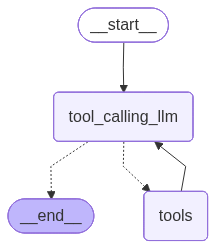

In [23]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

#### **Graph calling**

In [26]:
messages = graph_builder.invoke({"messages": "Hi, my name is Kunal. When is Argentina's first match in Fifa world cup and with whom?"})

In [27]:
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi, my name is Kunal. When is Argentina's first match in Fifa world cup and with whom?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (b5am57mzb)
 Call ID: b5am57mzb
  Args:
    query: Argentina first match in Fifa world cup
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Argentina at the FIFA World Cup - Wikipedia", "url": "https://en.wikipedia.org/wiki/Argentina_at_the_FIFA_World_Cup", "content": "## World Cup Finals\n\n### 1930 v Uruguay\n\nThe inaugural FIFA World Cup tournament culminated with Argentina facing hosts and current Olympic champions Uruguay. The match was turned twice: Argentina went into half-time with a 2–1 lead in spite of an early goal for Uruguay, but the hosts ultimately won 4–2. Guillermo Stábile, one of Argentina's scorers, beca